# 5. Exploratory Data Analysis (EDA)

L'EDA (Exploratory Data Analysis) consiste à explorer et analyser les données nettoyées afin de mieux comprendre leur distribution, détecter les valeurs inhabituelles et identifier les relations entre les variables et le temps de livraison.

Nous allons utiliser des statistiques, des regroupements et des visualisations pour découvrir les principaux patterns du dataset.

### 5.1 Vue générale du dataset

Nous commençons par examiner la structure générale du dataset après le nettoyage.

Cette étape permet de vérifier le nombre de lignes et de colonnes, les types des variables et les principales statistiques numériques.

In [5]:
import pandas as pd
import numpy as np

In [8]:
clean_df = pd.read_csv('../data/cleaned_data.csv')
clean_df.head()


,Delivery_person_Age,Delivery_person_Ratings,Restaurant_latitude,Restaurant_longitude,Delivery_location_latitude,Delivery_location_longitude,Order_Date,Weatherconditions,Road_traffic_density,Type_of_vehicle,multiple_deliveries,Time_taken(min),distance,order_hour,pickup_hour
0,37.0,4.9,22.745049,75.892471,22.765049,75.912471,2022-03-19,Sunny,High,motorcycle,0.0,24,3.020737,11.0,11
1,34.0,4.5,12.913041,77.683237,13.043041,77.813237,2022-03-25,Stormy,Jam,scooter,1.0,33,20.143737,19.0,19
2,23.0,4.4,12.914264,77.678400,12.924264,77.688400,2022-03-19,Sandstorms,Low,motorcycle,1.0,26,1.549693,8.0,8
3,38.0,4.7,11.003669,76.976494,11.053669,77.026494,2022-04-05,Sunny,Medium,motorcycle,1.0,21,7.774497,18.0,18
4,32.0,4.6,12.972793,80.249982,13.012793,80.289982,2022-03-26,Cloudy,High,scooter,1.0,30,6.197898,13.0,13


In [10]:
clean_df.shape


(41522, 15)

In [20]:
clean_df.describe().T

,count,mean,std,min,25%,50%,75%,max
Delivery_person_Age,41522.0,29.568807,5.655790,20.000000,25.000000,30.000000,34.000000,39.000000
Delivery_person_Ratings,41522.0,4.634261,0.321795,1.000000,4.500000,4.700000,4.800000,5.000000
Restaurant_latitude,41522.0,18.896960,5.461033,9.957144,12.986047,19.060834,22.751234,30.914057
Restaurant_longitude,41522.0,76.914307,3.493224,72.768726,73.897902,76.618203,78.368855,88.433452
Delivery_location_latitude,41522.0,18.960623,5.462841,9.967144,13.065662,19.115838,22.818060,31.054057
Delivery_location_longitude,41522.0,76.977970,3.493405,72.778726,73.939315,76.663067,78.403391,88.563452
multiple_deliveries,41522.0,0.750710,0.567383,0.000000,0.000000,1.000000,1.000000,3.000000
Time_taken(min),41522.0,26.315447,9.380634,10.000000,19.000000,26.000000,32.000000,54.000000
distance,41522.0,9.704133,5.593935,1.463837,4.648474,9.177295,13.659637,20.942906
order_hour,41522.0,17.471051,4.746506,0.000000,15.000000,19.000000,21.000000,23.000000


In [21]:
clean_df.duplicated().sum()

np.int64(0)

In [11]:
clean_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 41522 entries, 0 to 41521
Data columns (total 15 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   Delivery_person_Age          41522 non-null  float64
 1   Delivery_person_Ratings      41522 non-null  float64
 2   Restaurant_latitude          41522 non-null  float64
 3   Restaurant_longitude         41522 non-null  float64
 4   Delivery_location_latitude   41522 non-null  float64
 5   Delivery_location_longitude  41522 non-null  float64
 6   Order_Date                   41522 non-null  str    
 7   Weatherconditions            41522 non-null  str    
 8   Road_traffic_density         41522 non-null  str    
 9   Type_of_vehicle              41522 non-null  str    
 10  multiple_deliveries          41522 non-null  float64
 11  Time_taken(min)              41522 non-null  int64  
 12  distance                     41522 non-null  float64
 13  order_hour                 

### 5.2 Analyse de la variable cible

La variable cible de notre projet est `Time_taken(min)`, qui représente le temps total nécessaire pour effectuer une livraison.

Nous allons analyser sa distribution et ses statistiques afin de mieux comprendre les temps de livraison dans notre dataset.

In [19]:
clean_df["Time_taken(min)"].describe().T

count    41522.000000
mean        26.315447
std          9.380634
min         10.000000
25%         19.000000
50%         26.000000
75%         32.000000
max         54.000000
Name: Time_taken(min), dtype: float64

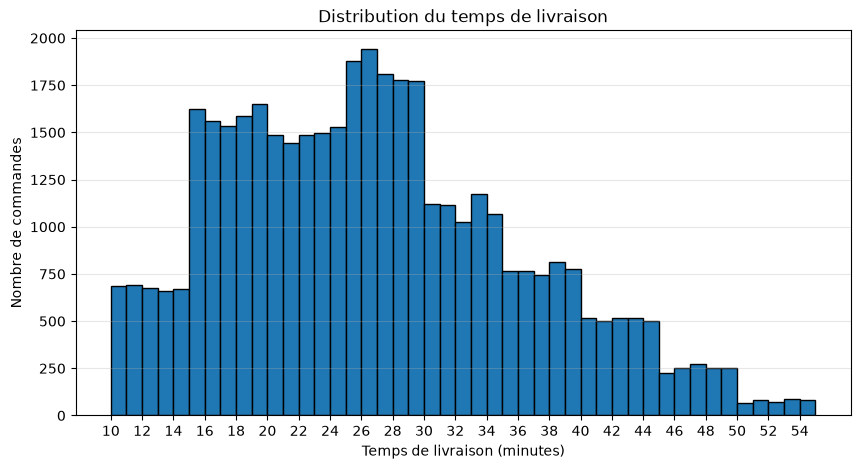

In [23]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))

plt.hist(
    clean_df["Time_taken(min)"],
    bins=range(10, 56),
    edgecolor="black"
)

plt.xlabel("Temps de livraison (minutes)")
plt.ylabel("Nombre de commandes")
plt.title("Distribution du temps de livraison")
plt.xticks(range(10, 55, 2))
plt.grid(axis="y", alpha=0.3)

plt.show()

### 5.3 Analyse des variables numériques

Nous allons maintenant analyser les principales variables numériques du dataset.

Cette étape permet d'observer leur distribution, leurs valeurs minimales et maximales, ainsi que d'identifier d'éventuelles valeurs inhabituelles.

In [26]:
numerical_cols = [
    "Delivery_person_Age",
    "multiple_deliveries",
    "order_hour",
    "pickup_hour",
    "distance"
]

clean_df[numerical_cols].describe()

,Delivery_person_Age,multiple_deliveries,order_hour,pickup_hour,distance
count,41522.000000,41522.000000,41522.000000,41522.000000,41522.000000
mean,29.568807,0.750710,17.471051,17.145971,9.704133
std,5.655790,0.567383,4.746506,5.318611,5.593935
min,20.000000,0.000000,0.000000,0.000000,1.463837
25%,25.000000,0.000000,15.000000,14.000000,4.648474
50%,30.000000,1.000000,19.000000,19.000000,9.177295
75%,34.000000,1.000000,21.000000,21.000000,13.659637
max,39.000000,3.000000,23.000000,23.000000,20.942906


### 5.3.1 Distribution de l'âge des livreurs

Nous allons visualiser la distribution de l'âge des livreurs afin d'observer les âges les plus fréquents et la répartition générale de cette variable.

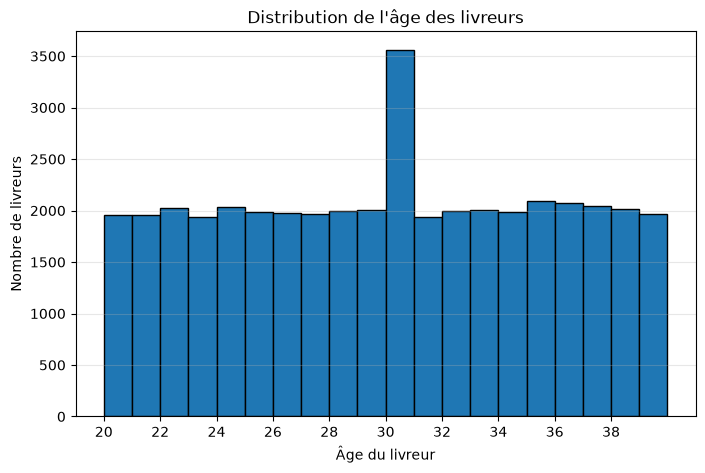

In [25]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))

plt.hist(
    clean_df["Delivery_person_Age"],
    bins=range(20, 41),
    edgecolor="black"
)

plt.xlabel("Âge du livreur")
plt.ylabel("Nombre de livreurs")
plt.title("Distribution de l'âge des livreurs")
plt.xticks(range(20, 40, 2))
plt.grid(axis="y", alpha=0.3)

plt.show()

### 5.3.2 Analyse des livraisons multiples

La variable `multiple_deliveries` indique le nombre de livraisons multiples associées à une commande.

Nous allons observer la fréquence de chaque valeur afin de comprendre leur répartition dans le dataset.

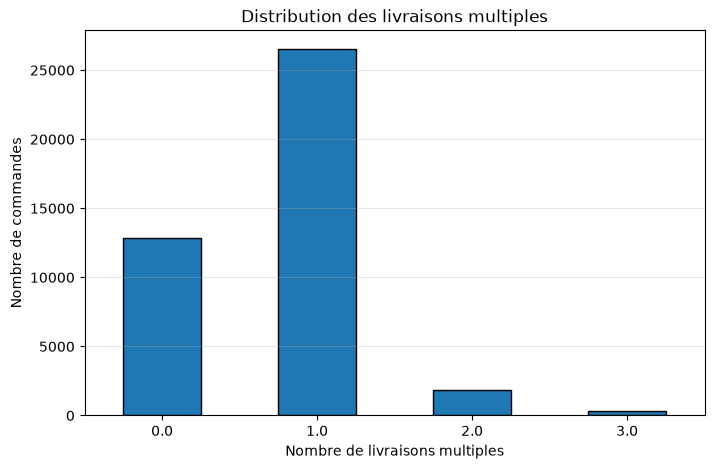

In [31]:
clean_df["multiple_deliveries"].value_counts().sort_index().plot(
    kind="bar",
    figsize=(8, 5),
    edgecolor="black"
)

plt.xlabel("Nombre de livraisons multiples")
plt.ylabel("Nombre de commandes")
plt.title("Distribution des livraisons multiples")
plt.xticks(rotation=0)
plt.grid(axis="y", alpha=0.3)

plt.show()

### 5.3.3 Analyse de l'heure de commande

Nous allons analyser la répartition des commandes selon l'heure de la journée afin d'identifier les périodes où les commandes sont les plus fréquentes.

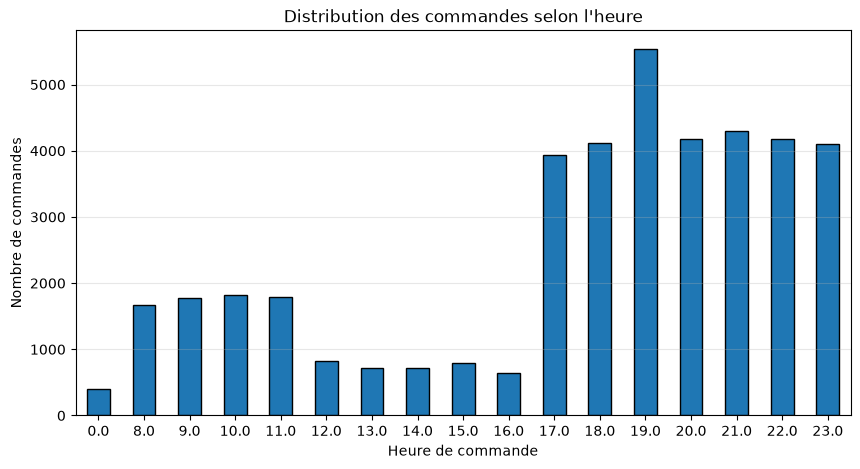

In [32]:
plt.figure(figsize=(10, 5))

clean_df["order_hour"].value_counts().sort_index().plot(
    kind="bar",
    edgecolor="black"
)

plt.xlabel("Heure de commande")
plt.ylabel("Nombre de commandes")
plt.title("Distribution des commandes selon l'heure")
plt.xticks(rotation=0)
plt.grid(axis="y", alpha=0.3)

plt.show()

### 5.3.4 Analyse de l'heure de récupération

Nous allons analyser la répartition des commandes selon l'heure de récupération afin d'identifier les périodes les plus fréquentes.

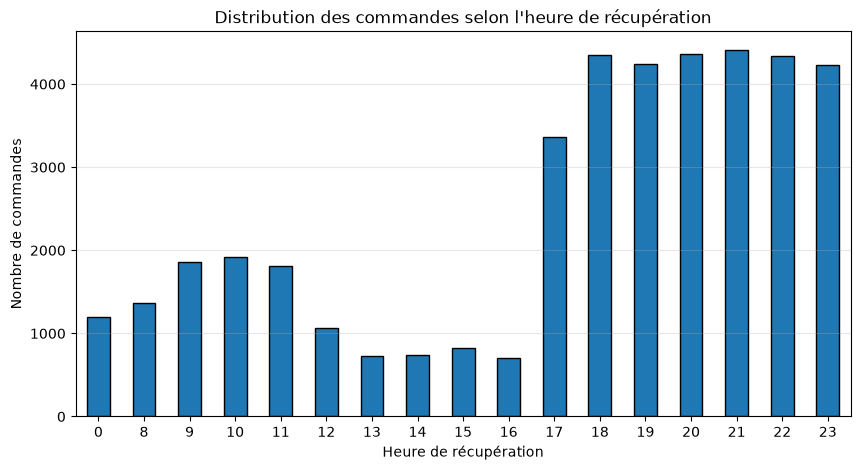

In [34]:
plt.figure(figsize=(10, 5))

clean_df["pickup_hour"].value_counts().sort_index().plot(
    kind="bar",
    edgecolor="black"
)

plt.xlabel("Heure de récupération")
plt.ylabel("Nombre de commandes")
plt.title("Distribution des commandes selon l'heure de récupération")
plt.xticks(rotation=0)
plt.grid(axis="y", alpha=0.3)

plt.show()

### 5.3.5 Analyse de la distance de livraison

Nous allons analyser la distribution de la distance entre le restaurant et le lieu de livraison.

Cette analyse permet de comprendre les distances généralement parcourues et d'identifier d'éventuelles valeurs inhabituelles.

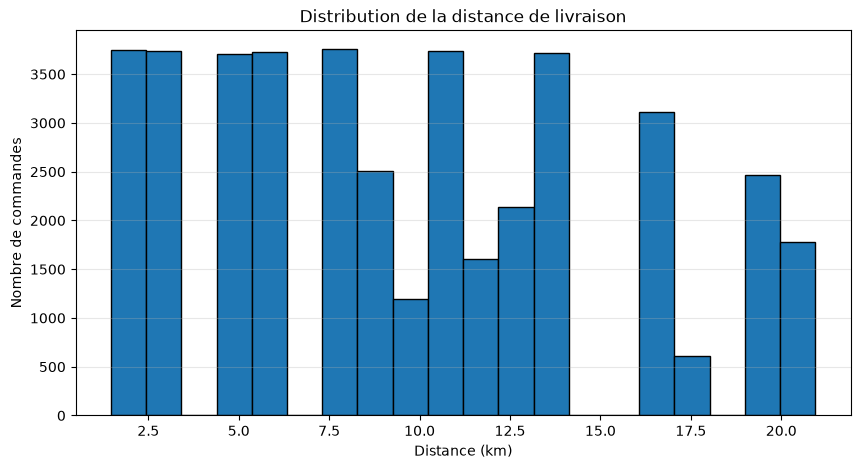

In [35]:
plt.figure(figsize=(10, 5))

plt.hist(
    clean_df["distance"],
    bins=20,
    edgecolor="black"
)

plt.xlabel("Distance (km)")
plt.ylabel("Nombre de commandes")
plt.title("Distribution de la distance de livraison")
plt.grid(axis="y", alpha=0.3)

plt.show()